In [ ]:
# Optional environment setup for Google Colab
import os
import sys
import subprocess

IS_COLAB = 'google.colab' in sys.modules
print(f"Running in Colab: {IS_COLAB}")

if IS_COLAB:
    # Uncomment if your data is stored in Google Drive.
    # from google.colab import drive
    # drive.mount('/content/drive')

    required = {
        'imblearn': 'imbalanced-learn'
    }

    for module_name, package_name in required.items():
        try:
            __import__(module_name)
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

    print('Colab setup complete. Ensure dataset files are in the current working directory or update paths accordingly.')

Running in Colab: True
Colab setup complete. Ensure dataset files are in the current working directory or update paths accordingly.


In [ ]:
#import libraries
import itertools
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time
from sklearn import metrics
import random

# Fix seeds for reproducibility
random.seed(42)        # Python random module
np.random.seed(42)     # NumPy random

In [ ]:
#Convert datasets to CSV
train = pd.read_csv('kddcup.data_10_percent.gz', compression='gzip', header=0, sep=',', quotechar='"')
train.to_csv('./KDD_CUP_train.csv')

In [ ]:
import zipfile
import gzip
import pandas as pd
import os

# Step 1: Extract the ZIP file
zip_path = "corrected.gz.zip"  # Ensure this is the correct filename
extract_folder = "extracted_files"  # Folder to extract contents

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)  # Extract files

# Step 2: Find the extracted GZ file
gz_file = None
for file in os.listdir(extract_folder):
    if file.endswith(".gz"):
        gz_file = os.path.join(extract_folder, file)  # Full path to the .gz file
        break

if gz_file:
    # Step 3: Read the GZ file as a CSV
    test = pd.read_csv(gz_file, compression='gzip', header=0, sep=',', quotechar='"')

    # Step 4: Save the data as a CSV
    output_file = "KDD_CUP_test.csv"
    test.to_csv(output_file, index=False)
    print(f"File successfully saved as {output_file}")
else:
    print("Error: No .gz file found after extracting the ZIP.")


File successfully saved as KDD_CUP_test.csv


In [ ]:
df = pd.read_csv("KDD_CUP_train.csv")
test_df = pd.read_csv("KDD_CUP_test.csv")

In [ ]:
df.head()

,Unnamed: 0,0,tcp,http,SF,181,5450,0.1,0.2,0.3,...,9.1,1.00.1,0.00.6,0.11,0.00.7,0.00.8,0.00.9,0.00.10,0.00.11,normal.
0,0,0,tcp,http,SF,239,486,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
1,1,0,tcp,http,SF,235,1337,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
2,2,0,tcp,http,SF,219,1337,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,3,0,tcp,http,SF,217,2032,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.
4,4,0,tcp,http,SF,217,2032,0,0,0,...,59,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [ ]:
test_df.head()

,0,udp,private,SF,105,146,0.1,0.2,0.3,0.4,...,254,1.00.1,0.01,0.00.6,0.00.7,0.00.8,0.00.9,0.00.10,0.00.11,normal.
0,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
3,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
4,0,udp,private,SF,105,146,0,0,0,0,...,255,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.


In [ ]:
col_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
             'dst_bytes','land', 'wrong_fragment', 'urgent', 'hot',
             'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
             'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
             'num_access_files', 'num_outbound_cmds', 'is_host_login',
             'is_guest_login', 'count', 'srv_count', 'serror_rate',
             'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
             'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
             'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
             'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
             'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
             'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
             'dst_host_srv_rerror_rate', 'label']

df = pd.read_csv('./KDD_CUP_train.csv', header=None, names=col_names, low_memory=False)
df = df.dropna()

In [ ]:
df_test = pd.read_csv('./KDD_CUP_test.csv', header=None, names=col_names, low_memory=False)
df_test = df_test.dropna()

In [ ]:
df = df.iloc[1:]
df_test = df_test.iloc[1:]

In [ ]:
df = df.drop_duplicates()
df_test = df_test.drop_duplicates()

In [ ]:
df.shape

(145585, 42)

In [ ]:
df_test.shape

(77291, 42)

In [ ]:
#convert the data type as in the original dataset
to_num_cols = ["srv_serror_rate", "rerror_rate", "srv_rerror_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
                             "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate"]
#train data set
for column in to_num_cols:
  df[column] = df[column].astype('float64')
  df_test[column] = df_test[column].astype('float64')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145585 entries, 0.0 to 494019.0
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     145585 non-null  int64  
 1   protocol_type                145585 non-null  object 
 2   service                      145585 non-null  object 
 3   flag                         145585 non-null  object 
 4   src_bytes                    145585 non-null  int64  
 5   dst_bytes                    145585 non-null  int64  
 6   land                         145585 non-null  float64
 7   wrong_fragment               145585 non-null  float64
 8   urgent                       145585 non-null  float64
 9   hot                          145585 non-null  float64
 10  num_failed_logins            145585 non-null  float64
 11  logged_in                    145585 non-null  int64  
 12  num_compromised              145585 non-null  float64
 13  

## Exploratory Data Analysis
This section inspects schema, summary statistics, and class distribution to characterize the dataset before feature transformations.

In [ ]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,145585.000000,1.455850e+05,1.455850e+05,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,...,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000,145585.000000
mean,132.026088,7.995753e+03,2.859762e+03,0.000137,0.020201,0.000048,0.100175,0.000515,0.491486,0.026177,...,181.469362,129.935508,0.553219,0.061389,0.092825,0.019048,0.291599,0.290980,0.110464,0.107676
std,1224.161209,1.820390e+06,6.081000e+04,0.011720,0.239369,0.010150,1.426803,0.028586,0.499929,3.311384,...,99.097507,114.714785,0.456236,0.147021,0.241124,0.060410,0.452493,0.453448,0.306098,0.304221
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,78.000000,12.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.470000e+02,1.050000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,117.000000,0.770000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.880000e+02,1.164000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.030000,0.020000,1.000000,1.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(df['label'].value_counts())

label
normal.             87831
neptune.            51820
back.                 968
teardrop.             918
satan.                906
warezclient.          893
ipsweep.              651
smurf.                641
portsweep.            416
pod.                  206
nmap.                 158
guess_passwd.          53
buffer_overflow.       30
warezmaster.           20
land.                  19
imap.                  12
rootkit.               10
loadmodule.             9
ftp_write.              8
multihop.               7
phf.                    4
perl.                   3
spy.                    2
Name: count, dtype: int64


In [ ]:
len(df['label'].value_counts())

23

In [ ]:
all_features = df.columns.tolist()

categorical_columns = ['protocol_type', 'service', 'flag', 'label', 'land', 'logged_in', 'is_host_login', 'is_guest_login']
numerical_columns = [feature for feature in all_features if feature not in categorical_columns and feature != 'label']

In [ ]:
def categorize_labels(df, column_name):
  category_mapping = {
      'normal' : 'normal.',
      'DoS': ['back.', 'land.', 'neptune.', 'pod.', 'smurf.', 'teardrop.'],
      'Probe': ['satan.', 'ipsweep.', 'nmap.', 'portsweep.'],
      'R2L': ['guess_passwd.', 'ftp_write.', 'imap.', 'phf.', 'multihop.',
                'warezmaster.', 'warezclient.', 'spy.'],
      'U2R': ['buffer_overflow.', 'loadmodule.', 'rootkit.', 'perl.']
  }

  for category, labels in category_mapping.items():
        df[column_name] = df[column_name].replace(labels, category)

  return df

In [ ]:
df = categorize_labels(df, 'label')

In [ ]:
df['label'].value_counts()

,count
label,
normal,87831
DoS,54572
Probe,2131
R2L,999
U2R,52


In [ ]:
len(numerical_columns)

34

## Feature Engineering
### Feature Mapping
Categorical protocol, flag, and service fields are mapped to numeric representations for modeling.

### Protocol Type Mapping

In [ ]:
df['protocol_type'].value_counts()

,count
protocol_type,
tcp,130912
udp,12267
icmp,2406


In [ ]:
pmap = {'icmp':0,'tcp':1,'udp':2}
df['protocol_type'] = df['protocol_type'].map(pmap)
df_test['protocol_type'] = df_test['protocol_type'].map(pmap)


### TCP Flag Mapping

In [ ]:
df['flag'].value_counts()

,count
flag,
SF,87458
S0,42278
REJ,14712
RSTO,569
RSTR,425
S1,57
SH,34
S2,24
RSTOS0,11


In [ ]:
fmap = {'SF':0,'S0':1,'REJ':2,'RSTR':3,'RSTO':4,'SH':5 ,'S1':6 ,'S2':7,'RSTOS0':8,'S3':9 ,'OTH':10}
df['flag'] = df['flag'].map(fmap)
df_test['flag'] = df_test['flag'].map(fmap)

### Service Mapping

In [ ]:
df['service'].value_counts()

,count
service,
http,62053
private,49057
smtp,9721
domain_u,5425
other,4769
...,...
X11,11
tim_i,5
pm_dump,1


In [ ]:
# Assuming df['service'].value_counts() gives a series
service_counts = df['service'].value_counts()

# Convert the values (counts) into a list
service_names_list = service_counts.index.tolist()

# Print the list of service names
print(service_names_list)

['http', 'private', 'smtp', 'domain_u', 'other', 'ftp_data', 'ecr_i', 'eco_i', 'ftp', 'finger', 'telnet', 'urp_i', 'auth', 'ntp_u', 'pop_3', 'time', 'csnet_ns', 'remote_job', 'gopher', 'imap4', 'discard', 'systat', 'iso_tsap', 'domain', 'echo', 'shell', 'rje', 'sql_net', 'whois', 'printer', 'nntp', 'courier', 'netbios_ssn', 'mtp', 'sunrpc', 'klogin', 'vmnet', 'uucp_path', 'ssh', 'nnsp', 'uucp', 'supdup', 'bgp', 'hostnames', 'login', 'daytime', 'netbios_ns', 'link', 'ldap', 'efs', 'pop_2', 'http_443', 'exec', 'name', 'kshell', 'netbios_dgm', 'ctf', 'netstat', 'Z39_50', 'IRC', 'urh_i', 'X11', 'tim_i', 'pm_dump', 'tftp_u', 'red_i']


In [ ]:
smap = {'ecr_i':0, 'private':1, 'http':2, 'smtp':3, 'other':4, 'domain_u':5, 'ftp_data':6, 'eco_i':7, 'ftp':8,
        'finger':9, 'urp_i':10, 'telnet':11, 'ntp_u':12, 'auth':13, 'pop_3':14, 'time':15, 'csnet_ns':16, 'remote_job':17,
        'gopher':18, 'imap4':19, 'discard':20, 'domain':21, 'iso_tsap':22, 'systat':23, 'shell':24, 'echo':25, 'rje':26,
        'whois':27, 'sql_net':28, 'printer':29, 'nntp':30, 'courier':31, 'sunrpc':32, 'netbios_ssn':33, 'mtp':34,
        'vmnet':35, 'uucp_path':36, 'uucp':37, 'klogin':38, 'bgp':39, 'ssh':40, 'supdup':41, 'nnsp':42,
        'login':43, 'hostnames':44, 'efs':45, 'daytime':46, 'link':47, 'netbios_ns':48, 'pop_2':49,
        'ldap':50, 'netbios_dgm':51, 'exec':52, 'http_443':53, 'kshell':54, 'name':55, 'ctf':56,
        'netstat':57, 'Z39_50':58, 'IRC':59, 'urh_i':60, 'X11':61, 'tim_i':62, 'pm_dump':63, 'tftp_u':64, 'red_i':65}
df['service'] = df['service'].map(smap)
df_test['service'] = df_test['service'].map(smap)

## Data Preprocessing
### Dataset Splitting
Training/test partitions are prepared here for subsequent scaling, imbalance handling, and model training.

In [ ]:
from sklearn.model_selection import train_test_split

# Target variable and train set
Y = df[['label']]
X = df.drop(['label',], axis=1)

# Split test and train data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(101909, 41) (43676, 41)
(101909, 1) (43676, 1)


### Scaling Numerical Attributes

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Select numerical features
X_train_num = X_train[numerical_columns]
X_test_num = X_test[numerical_columns]
#X_val_num = X_val[numerical_columns]

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)  # Fit and transform on training data
X_test_scaled = scaler.transform(X_test_num)       # Transform on test data
#X_val_scaled = scaler.transform(X_val_num)

# Replace the numerical features in the DataFrame with their scaled values
X_train[numerical_columns] = X_train_scaled
X_test[numerical_columns] = X_test_scaled
#X_val[numerical_columns] = X_val_scaled

# Print shapes to verify
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


#corected dataset
df_test_num = df_test[numerical_columns]
df_test_scaled = scaler.transform(df_test_num)
df_test[numerical_columns] = df_test_scaled
print(df_test.shape)

(101909, 41) (43676, 41)
(101909, 1) (43676, 1)
(77291, 42)


### Data Imbalance Treatment
Class imbalance is handled using controlled over-sampling and under-sampling before model fitting.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter

In [ ]:
y_train.value_counts()

,count
label,
normal,61458
DoS,38212
Probe,1491
R2L,710
U2R,38


In [ ]:
from collections import Counter

# Convert y_train.value_counts() to a dictionary with string keys
y_counts_dict = {key[0] if isinstance(key, tuple) else key: value for key, value in y_train.value_counts().to_dict().items()}

# Convert to Counter format
class_counts = Counter(y_counts_dict)

print(class_counts)

Counter({'normal': 61458, 'DoS': 38212, 'Probe': 1491, 'R2L': 710, 'U2R': 38})


In [ ]:
majority_class = max(class_counts, key=class_counts.get)  # Identify majority class
majority_size = class_counts[majority_class]

In [ ]:
threshold = 0.50 * majority_size
minority_classes = {cls: count for cls, count in class_counts.items() if count < threshold}

In [ ]:
minority_classes

{'Probe': 1491, 'R2L': 710, 'U2R': 38}

In [ ]:
threshold = 0.5 * majority_size

In [ ]:
smote = SMOTE(sampling_strategy={cls: int(threshold) for cls in minority_classes}, random_state=42)

In [ ]:
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
target_size = int(0.5 * majority_size)

In [ ]:
# Convert y_train.value_counts() to a dictionary with string keys
y_counts_dict = {key[0] if isinstance(key, tuple) else key: value for key, value in y_resampled.value_counts().to_dict().items()}

# Convert to Counter format
class_counts_y_resampled = Counter(y_counts_dict)

print(class_counts_y_resampled)

Counter({'normal': 61458, 'DoS': 38212, 'Probe': 30729, 'R2L': 30729, 'U2R': 30729})


In [ ]:
rus = RandomUnderSampler(sampling_strategy={cls: target_size for cls in class_counts_y_resampled}, random_state=42)
X_final, y_final = rus.fit_resample(X_resampled, y_resampled)

print("Before Under-Sampling:")
print(y_resampled.value_counts())

print("\nAfter Under-Sampling:")
print(y_final.value_counts())

Before Under-Sampling:
label 
normal    61458
DoS       38212
Probe     30729
R2L       30729
U2R       30729
Name: count, dtype: int64

After Under-Sampling:
label 
DoS       30729
Probe     30729
R2L       30729
U2R       30729
normal    30729
Name: count, dtype: int64


In [ ]:
# Convert y_train.value_counts() to a dictionary with string keys
y_counts_dict = {key[0] if isinstance(key, tuple) else key: value for key, value in y_final.value_counts().to_dict().items()}

# Convert to Counter format
class_counts_y_final = Counter(y_counts_dict)

print("Final class distribution:", class_counts_y_final)

Final class distribution: Counter({'DoS': 30729, 'Probe': 30729, 'R2L': 30729, 'U2R': 30729, 'normal': 30729})


In [ ]:
X_train = X_final
y_train = y_final

## Model Development
This section defines the classifier and feature-selection routine, then trains and applies the model using the prepared feature space.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
import time

# Cache to avoid redundant evaluations
fitness_cache = {}

def evaluate_fitness(solution):
    """
    Fitness function for HBA-ABC feature selection.
    Objective: minimize (1 - F1-score).
    """
    key = tuple(solution)
    if key in fitness_cache:
        return fitness_cache[key]

    # Identify selected feature indices
    selected_features = np.where(solution == 1)[0]
    if len(selected_features) == 0:
        fitness_cache[key] = (1.0, 0.0)   # FIXED
        return 1.0, 0.0

    # Select features
    if isinstance(X_train, np.ndarray):
        X_train_subset = X_train[:, selected_features]
        X_test_subset = X_test[:, selected_features]
    else:
        X_train_subset = X_train.iloc[:, selected_features]
        X_test_subset = X_test.iloc[:, selected_features]

    # Sample 70% of training data
    X_train_sampled, _, y_train_sampled, _ = train_test_split(
        X_train_subset, y_train, train_size=0.7, stratify=y_train, random_state=42
    )

    # Classifier
    clf = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)
    clf.fit(X_train_sampled, y_train_sampled)
    y_pred = clf.predict(X_test_subset)

    raw_f1 = f1_score(y_test, y_pred, average='macro')

    alpha = 1.0
    beta = 0.1
    penalty = beta * (len(selected_features) / X_train.shape[1])
    score = alpha * raw_f1 - penalty

    fitness = 1 - score

    fitness_cache[key] = (fitness, raw_f1)
    return fitness, raw_f1

In [ ]:
def HBA_ABC_feature_selection(X_train, X_test, y_train, y_test,
                              population_size=20, max_iter=200,
                              patience=100):

    num_features = X_train.shape[1]

    # Initialize population
    population = np.random.randint(2, size=(population_size, num_features))

    # Evaluate initial population
    results = [evaluate_fitness(ind) for ind in population]
    fitness = np.array([r[0] for r in results])
    f1_scores = np.array([r[1] for r in results])

    # Best solution
    best_idx = np.argmin(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]
    best_f1 = f1_scores[best_idx]

    # Early stopping
    no_improvement_count = 0
    best_fitness_history = [best_fitness]

    # --- Main Loop ---
    for t in range(max_iter):
        for i in range(population_size):

            # ===== ABC Exploration =====
            j = np.random.randint(num_features)
            k = np.random.randint(population_size)
            while k == i:
                k = np.random.randint(population_size)

            phi = np.random.uniform(-1, 1)
            candidate = population[i].copy()
            if np.random.rand() < abs(phi):
                candidate[j] = 1 - candidate[j]

            # ===== HBA Exploitation =====
            distance = np.linalg.norm(candidate - best_solution) + 1e-9
            intensity = 1 / (4 * np.pi * distance ** 2)
            beta = np.random.rand()
            adaptive_prob = np.clip(intensity * beta, 0, 1)

            for d in range(num_features):
                if np.random.rand() < adaptive_prob:
                    candidate[d] = 1 - candidate[d]

            # ===== Evaluate =====
            candidate_fit, candidate_f1 = evaluate_fitness(candidate)

            # Greedy selection
            if candidate_fit < fitness[i]:
                population[i] = candidate
                fitness[i] = candidate_fit
                f1_scores[i] = candidate_f1

        # ===== Global Best Update =====
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_fitness:
            best_solution = population[best_idx].copy()
            best_fitness = fitness[best_idx]
            best_f1 = f1_scores[best_idx]
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        best_fitness_history.append(best_fitness)

        print(f"Iteration {t+1}/{max_iter} | Best Fitness: {best_fitness:.4f} | F1 Score: {best_f1:.4f} | No Improvement: {no_improvement_count}")

        # Early stopping
        if no_improvement_count >= patience:
            print(f"\nEarly stopping triggered after {t+1} iterations "
                  f"(no improvement for {patience} consecutive iterations).")
            break

    return best_solution, best_fitness, best_f1


In [ ]:
X_train, X_test_model, y_train, y_test_model = train_test_split(X_train, y_train, test_size=0.30, random_state=42)


start_time = time.time()

best_solution, best_fitness, best_f1 = HBA_ABC_feature_selection(
    X_train, X_test_model, y_test_model, y_test
)

selected_features = np.where(best_solution == 1)[0]

print(f"\n✅ Selected {len(selected_features)} features out of {X_train.shape[1]}")
print(f"Best fitness (1 - F1): {best_fitness:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

end_time = time.time()

print(f"Training Time: {end_time - start_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Iteration 1/200 | Best Fitness: 0.0979 | F1 Score: 0.9533 | No Improvement: 1


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Iteration 2/200 | Best Fitness: 0.0979 | F1 Score: 0.9533 | No Improvement: 2


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

...

Iteration 198/200 | Best Fitness: 0.0740 | F1 Score: 0.9675 | No Improvement: 39


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Iteration 199/200 | Best Fitness: 0.0740 | F1 Score: 0.9675 | No Improvement: 40


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

Iteration 200/200 | Best Fitness: 0.0740 | F1 Score: 0.9675 | No Improvement: 41

✅ Selected 17 features out of 41
Best fitness (1 - F1): 0.0740
Best F1 Score: 0.9675
Training Time: 6269.63 seconds


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train on selected features
X_train_sel = X_train.iloc[:, selected_features]
X_test_sel = X_test.iloc[:, selected_features]

start_time = time.time()

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_sel, y_train)

# Record end time
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

y_pred = clf.predict(X_test_sel)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Time: 18.53 seconds

Classification Report:

              precision    recall  f1-score   support

         DoS     0.9997    0.9998    0.9997     16360
       Probe     0.9770    0.9953    0.9861       640
         R2L     0.9525    0.9723    0.9623       289
         U2R     0.8125    0.9286    0.8667        14
      normal     0.9995    0.9987    0.9991     26373

    accuracy                         0.9989     43676
   macro avg     0.9482    0.9789    0.9628     43676
weighted avg     0.9989    0.9989    0.9989     43676



In [ ]:
selected_feature_names = df.columns[selected_features]  # Convert indices to column names
X_unlabeled = df_test[selected_feature_names]  # Use names instead of indices

In [ ]:
# Predict pseudo-labels for the unlabeled dataset
pseudo_labels = clf.predict(X_unlabeled)  # X_unlabeled = features from corrected.gz
pseudo_probs = clf.predict_proba(X_unlabeled)  # Get prediction confidence scores

In [ ]:
selected_feature_names

Index(['duration', 'service', 'src_bytes', 'dst_bytes', 'wrong_fragment',
       'logged_in', 'num_root', 'num_access_files', 'is_guest_login',
       'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_srv_count',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate'],
      dtype='object')

In [ ]:
# Define a confidence threshold (e.g., 0.9)
confidence_threshold = 0.9
high_confidence_mask = np.max(pseudo_probs, axis=1) > confidence_threshold

# Select only high-confidence samples
X_pseudo = X_unlabeled[high_confidence_mask]
y_pseudo = pseudo_labels[high_confidence_mask]

print(f"Selected {len(y_pseudo)} high-confidence pseudo-labels.")

Selected 0 high-confidence pseudo-labels.


In [ ]:
# Merge labeled and pseudo-labeled data

X_combined = np.vstack((X_train_sel, X_pseudo))

# Convert y_train to 1D if it's a DataFrame
if hasattr(y_train, 'values'):
    y_train_flat = y_train.values.ravel()
else:
    y_train_flat = y_train.ravel()

# Now stack them safely
y_combined = np.hstack((y_train_flat, y_pseudo))

# Combine feature matrices
X_combined = np.vstack((X_train_sel, X_pseudo))

# Start timing the prediction
start_test_time = time.time()

# Retrain the model
clf.fit(X_combined, y_combined)


# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

Training Time: 18.53 seconds


In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
y_combined_pred = clf.predict(X_combined)
fintuned_train_accuracy = accuracy_score(y_combined, y_combined_pred)
print(f"Fine-Tuned Model Train Accuracy on KDDcp_10_percentage: {fintuned_train_accuracy:.4f}")

Fine-Tuned Model Train Accuracy on KDDcp_10_percentage: 1.0000


In [ ]:
import time
from sklearn.metrics import accuracy_score, classification_report

# Start timing the prediction
start_test_time = time.time()

# Predict on the labeled test set
y_pred_finetuned = clf.predict(X_test_sel)

# End timing the prediction
end_test_time = time.time()

# Convert y_train to 1D if it's a DataFrame
if hasattr(y_test, 'values'):
    y_test_flat = y_test.values.ravel()
else:
    y_test_flat = y_test.ravel()


# Compute accuracy
finetuned_accuracy = accuracy_score(y_test_flat, y_pred_finetuned)
print(f"Fine-Tuned Model Test Accuracy on KDDcp_10_percentage: {finetuned_accuracy:.4f}")

# Print classification report
print("Classification Report:\n", classification_report(y_test_flat, y_pred_finetuned, digits=4))

# Print test (prediction) runtime
test_runtime_seconds = end_test_time - start_test_time
print(f"\nTesting (Prediction) Runtime: {test_runtime_seconds:.4f} seconds")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Fine-Tuned Model Test Accuracy on KDDcp_10_percentage: 0.9989
Classification Report:
               precision    recall  f1-score   support

         DoS     0.9997    0.9998    0.9997     16360
       Probe     0.9770    0.9953    0.9861       640
         R2L     0.9525    0.9723    0.9623       289
         U2R     0.8125    0.9286    0.8667        14
      normal     0.9995    0.9987    0.9991     26373

    accuracy                         0.9989     43676
   macro avg     0.9482    0.9789    0.9628     43676
weighted avg     0.9989    0.9989    0.9989     43676


Testing (Prediction) Runtime: 0.4074 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


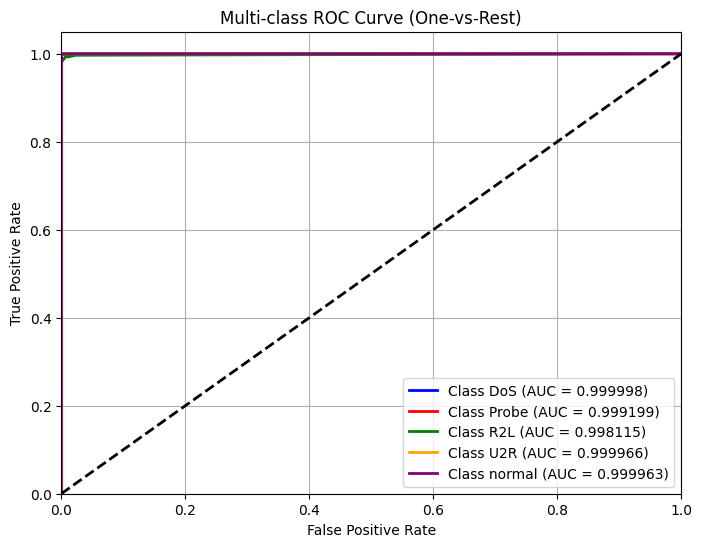

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output for multi-class ROC
classes = np.unique(y_test_flat)
y_test_bin = label_binarize(y_test_flat, classes=classes)
n_classes = y_test_bin.shape[1]

# Get prediction probabilities (you need a classifier that supports predict_proba)
y_score = clf.predict_proba(X_test_sel)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.6f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


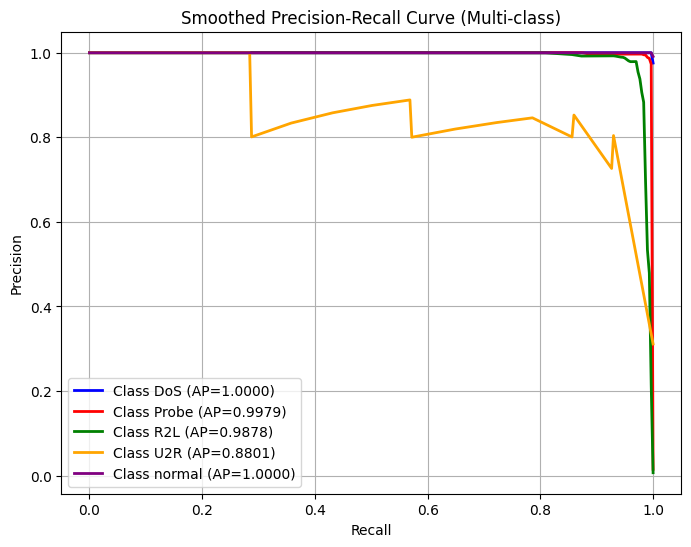

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

classes = np.unique(y_test_flat)
y_test_bin = label_binarize(y_test_flat, classes=classes)
n_classes = y_test_bin.shape[1]

y_score = clf.predict_proba(X_test_sel)

plt.figure(figsize=(8, 6))

colors = ['blue', 'red', 'green', 'orange', 'purple']

# Excel storage
pr_data_smooth = []

for i, color in zip(range(n_classes), colors):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_score[:, i]
    )

    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])

    # Convert to numpy
    recall = np.array(recall)
    precision = np.array(precision)

    # Sort for interpolation
    order = np.argsort(recall)
    recall = recall[order]
    precision = precision[order]

    # Smooth curve (300 points)
    recall_smooth = np.linspace(0, 1, 300)

    precision_smooth = interp1d(
        recall,
        precision,
        kind='linear',
        bounds_error=False,
        fill_value="extrapolate"
    )(recall_smooth)

    # Plot smooth curve
    plt.plot(recall_smooth, precision_smooth, lw=2,
             color=color,
             label=f'Class {classes[i]} (AP={ap:.4f})')

    # Save SMOOTH values to Excel
    for r, p in zip(recall_smooth, precision_smooth):
        pr_data_smooth.append([classes[i], r, p])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Smoothed Precision-Recall Curve (Multi-class)')
plt.legend()
plt.grid()
plt.show()

# Export to Excel
df_pr = pd.DataFrame(pr_data_smooth, columns=['Class', 'Recall', 'Precision'])
df_pr.to_excel('smooth_precision_recall.xlsx', index=False)


## Evaluation Metrics
Precision, recall, F1-score, confusion characteristics, and class-wise behavior are evaluated in this stage.

## Results and Discussion
Validation predictions are assessed on `validate_data.csv` to inspect generalization behavior on external data.

In [ ]:
validate_data = pd.read_csv("validate_data.csv")

In [ ]:
validate_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,DoS
1,1,tcp,private,RSTOS0,0,0,0,0,0,0,...,3,0.01,0.11,0.28,0.00,0.22,0.67,0.06,0.33,DoS
2,0,tcp,http,SF,287,2251,0,0,0,0,...,219,1.00,0.00,0.12,0.03,0.00,0.00,0.00,0.00,normal
3,0,tcp,private,S0,0,0,0,0,0,0,...,19,0.07,0.08,0.00,0.00,1.00,1.00,0.00,0.00,DoS
4,0,tcp,http,SF,233,616,0,0,0,0,...,255,1.00,0.00,0.02,0.03,0.00,0.00,0.02,0.00,normal


In [ ]:
validate_data['label'].value_counts()

,count
label,
normal,13
DoS,11
Probe,5
R2L,3
U2R,2


In [ ]:
validate_data['protocol_type'] = validate_data['protocol_type'].map(pmap)
validate_data['flag'] = validate_data['flag'].map(fmap)
validate_data['service'] = validate_data['service'].map(smap)

In [ ]:
X = validate_data.drop("label", axis=1)
y = validate_data["label"]

In [ ]:
X_selected = X.iloc[:, selected_features]

In [ ]:
X.applymap(lambda x: isinstance(x, str) and x.strip() == '').sum()

/tmp/ipykernel_1538/1243755848.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X.applymap(lambda x: isinstance(x, str) and x.strip() == '').sum()


,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
X = X.replace(' ', np.nan)
X = X.replace('', np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)  # or use another imputation strategy

In [ ]:
# Select numerical features
X_numeric = X[numerical_columns]

# Scale the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)  # Fit and transform on training data

# Replace the numerical features in the DataFrame with their scaled values
X[numerical_columns] = X_scaled

In [ ]:
X_selected = X.iloc[:, selected_features]

In [ ]:
y_pred = clf.predict(X_selected)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
import pandas as pd

# Convert array to DataFrame
y_pred_df = pd.DataFrame(y_pred, columns=['Predicted_Label'])

# Save to CSV
y_pred_df.to_csv('y_pred_results.csv', index=False)

print("✅ Predictions saved to 'y_pred_results.csv'")


✅ Predictions saved to 'y_pred_results.csv'


In [ ]:
print(y.dtype)
print(type(y_pred))
print(pd.Series(y_pred).dtype)

object
<class 'numpy.ndarray'>
object


In [ ]:
y = y.astype(str)
y_pred = pd.Series(y_pred).astype(str)

validation_train_accuracy = accuracy_score(y, y_pred)
print(f"Validation Accuracy: {validation_train_accuracy:.4f}")

Validation Accuracy: 0.7941


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Accuracy
validation_train_accuracy = accuracy_score(y, y_pred)
print(f"Validation Accuracy: {validation_train_accuracy:.4f}")

# Precision, Recall, F1 (macro = average across classes, good for imbalanced datasets)
precision = precision_score(y, y_pred, average='macro')
recall = recall_score(y, y_pred, average='macro')
f1 = f1_score(y, y_pred, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Detailed per-class metrics
print("\nClassification Report:")
print(classification_report(y, y_pred, digits = 4))

Validation Accuracy: 0.7941
Precision: 0.8766
Recall:    0.7424
F1-score:  0.7521

Classification Report:
              precision    recall  f1-score   support

         DoS     1.0000    0.5455    0.7059        11
       Probe     0.4545    1.0000    0.6250         5
         R2L     1.0000    0.6667    0.8000         3
         U2R     1.0000    0.5000    0.6667         2
      normal     0.9286    1.0000    0.9630        13

    accuracy                         0.7941        34
   macro avg     0.8766    0.7424    0.7521        34
weighted avg     0.8925    0.7941    0.7983        34

